<a href="https://colab.research.google.com/github/sx2413-eloise/clmt5405-final-project/blob/main/notebooks/global_sst_change.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Sea Surface Temperature Change

## Research Question

Has global sea surface temperature increased from 1981 to 2021, and where has warming been strongest?

In this notebook, I analyze the NOAA OISST dataset using Xarray. I focus on global-scale patterns of sea surface temperature, including global mean SST change over time, spatial maps of SST, and a warming trend map.



## Dataset

This notebook uses the NOAA Optimum Interpolated Sea Surface Temperature dataset from the LEAP Data Catalog. The dataset is stored as an analysis-ready Zarr dataset and is opened directly with Xarray. I use the `sst` variable, which represents daily sea surface temperature in degrees Celsius on a global 0.25-degree latitude-longitude grid.

The available time period in this Zarr store is from September 1981 to June 2021.

In [1]:
%pip install xarray zarr dask matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 51.6 MB/s eta 0:00:00


In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

## Loading the Data

The dataset is accessed directly from its cloud-hosted Zarr store. This means the notebook does not require any manual data download step.

In [3]:
store = "https://ncsa.osn.xsede.org/Pangeo/pangeo-forge/noaa_oisst/v2.1-avhrr.zarr"

ds = xr.open_dataset(store, engine="zarr", chunks={})
ds

<xarray.Dataset> Size: 241GB
Dimensions:  (time: 14532, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 116kB 1981-09-01T12:00:00 ... 2021-06-14T1...
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    anom     (time, zlev, lat, lon) float32 60GB dask.array<chunksize=(20, 1, 720, 1440), meta=np.ndarray>
    err      (time, zlev, lat, lon) float32 60GB dask.array<chunksize=(20, 1, 720, 1440), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float32 60GB dask.array<chunksize=(20, 1, 720, 1440), meta=np.ndarray>
    sst      (time, zlev, lat, lon) float32 60GB dask.array<chunksize=(20, 1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    Conventions:                CF-1.6, ACDD-1.3
    cdm_data_type:              Grid
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    creator_email:              oisst-help@noaa.gov
    creator_url:                https://www.ncei.noaa.gov/
    date_created:               2020-05-08T19:05:13Z
    ...                         ...
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    standard_name_vocabulary:   CF Standard Name Table (v40, 25 January 2017)
    summary:                    NOAAs 1/4-degree Daily Optimum Interpolation ...
    time_coverage_end:          1981-09-01T23:59:59Z
    time_coverage_start:        1981-09-01T00:00:00Z
    title:                      NOAA/NCEI 1/4 Degree Daily Optimum Interpolat...

In [4]:
sst = ds["sst"].squeeze()
sst

<xarray.DataArray 'sst' (time: 14532, lat: 720, lon: 1440)> Size: 60GB
dask.array<getitem, shape=(14532, 720, 1440), dtype=float32, chunksize=(20, 720, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 116kB 1981-09-01T12:00:00 ... 2021-06-14T1...
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
    zlev     float32 4B 0.0
Attributes:
    long_name:  Daily sea surface temperature
    units:      Celsius
    valid_max:  4500
    valid_min:  -300

## Initial SST Map

As a first check, I plot sea surface temperature for the first available day in the dataset. This confirms that the dataset loaded correctly and shows the expected global SST pattern, with warmer temperatures in the tropics and colder temperatures near the poles.

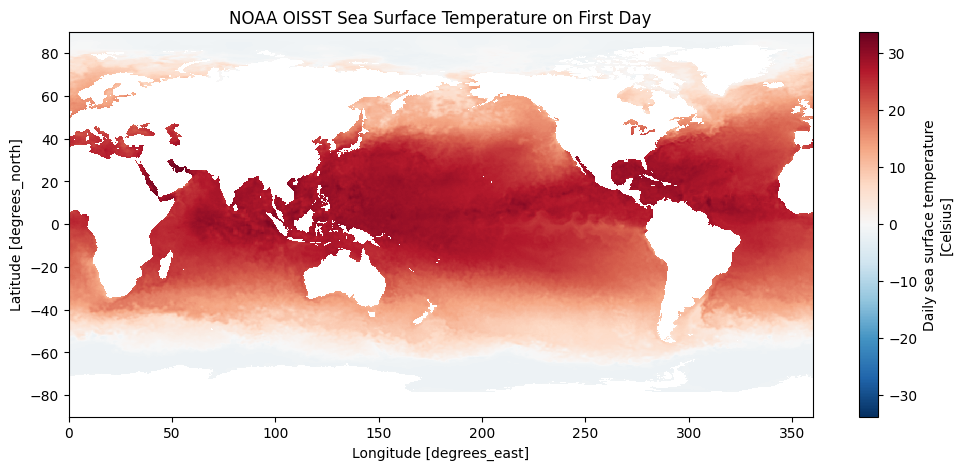

In [5]:
sst.isel(time=0).plot(figsize=(12, 5))
plt.title("NOAA OISST Sea Surface Temperature on First Day")
plt.show()

## Global Mean SST

To estimate global mean sea surface temperature, I compute a latitude-weighted average. This is necessary because grid cells near the poles represent smaller surface areas than grid cells near the equator. I then average the daily values into annual means to show long-term change more clearly.

In [6]:
weights = np.cos(np.deg2rad(sst.lat))
weights.name = "weights"

global_mean_daily = sst.weighted(weights).mean(dim=("lat", "lon"))

global_mean_annual = global_mean_daily.resample(time="YS").mean()

The annual global mean SST shows the long-term behavior of ocean surface temperature from 1981 to 2021. This figure is used to evaluate whether global sea surface temperature increased during the satellite observation era.

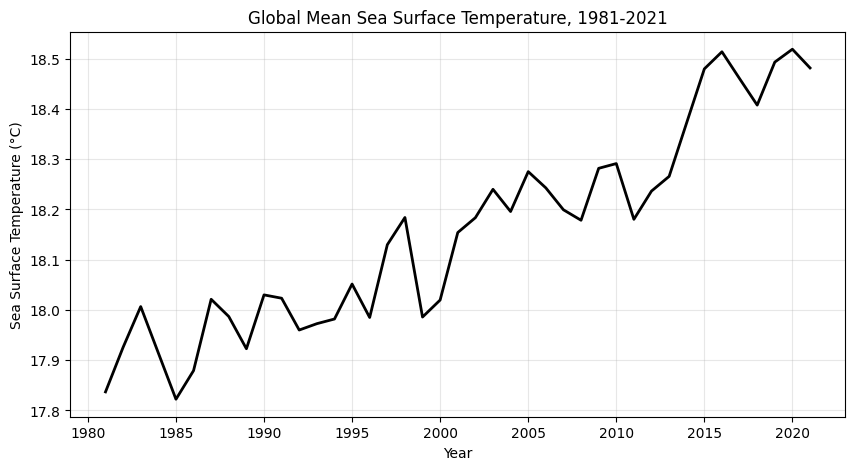

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

global_mean_annual.plot(ax=ax, color="black", linewidth=2)

ax.set_title("Global Mean Sea Surface Temperature, 1981-2021")
ax.set_xlabel("Year")
ax.set_ylabel("Sea Surface Temperature (°C)")
ax.grid(True, alpha=0.3)

plt.show()

## Decadal Mean SST Maps

Next, I compare average SST patterns between an early decade and a recent decade. I use 1982-1991 as the early period and 2012-2021 as the recent period. This comparison helps show whether the spatial pattern of SST changed between the beginning and end of the record.

In [8]:
sst_1980s = sst.sel(time=slice("1982-01-01", "1991-12-31")).mean("time")
sst_2010s = sst.sel(time=slice("2012-01-01", "2021-06-14")).mean("time")

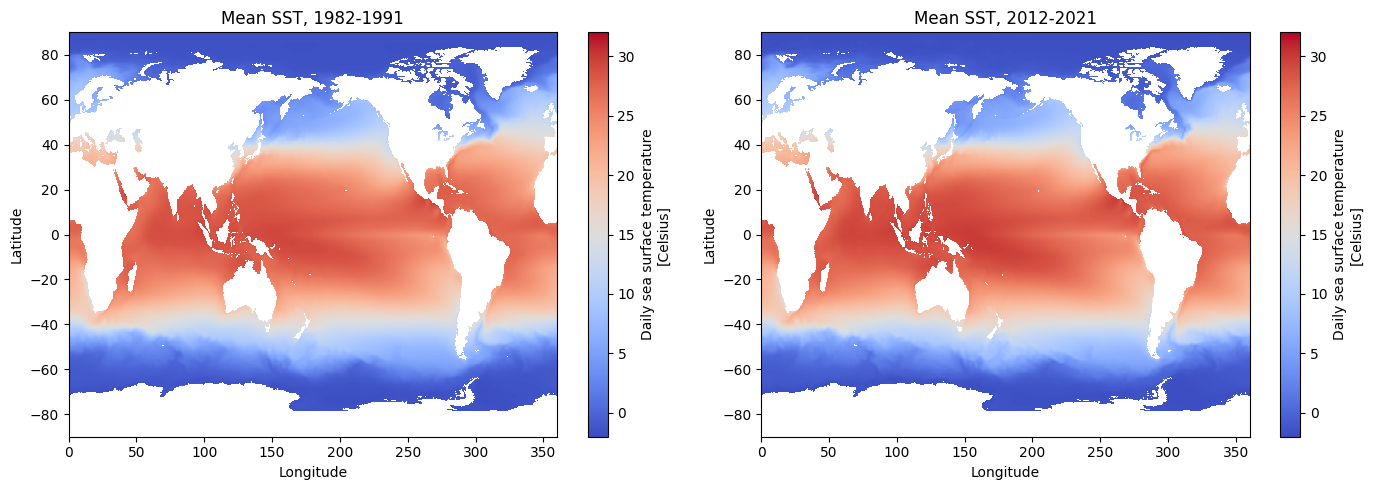

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sst_1980s.plot(ax=axes[0], cmap="coolwarm", vmin=-2, vmax=32)
axes[0].set_title("Mean SST, 1982-1991")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

sst_2010s.plot(ax=axes[1], cmap="coolwarm", vmin=-2, vmax=32)
axes[1].set_title("Mean SST, 2012-2021")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

## Warming Trend Map

To identify where sea surface temperature changed most rapidly, I calculate a linear trend at each grid point using annual mean SST. I first coarsen the original 0.25-degree data to 1-degree resolution to make the calculation faster and more stable in Colab. The trend is shown in degrees Celsius per decade.

In [10]:
sst_coarse = sst.coarsen(lat=4, lon=4, boundary="trim").mean()

In [11]:
sst_annual_coarse = sst_coarse.resample(time="YS").mean()

In [12]:
years = sst_annual_coarse.time.dt.year
sst_annual_coarse = sst_annual_coarse.assign_coords(year=("time", years.data))

In [13]:
trend = sst_annual_coarse.swap_dims({"time": "year"}).polyfit(dim="year", deg=1)
warming_rate = trend["polyfit_coefficients"].sel(degree=1)

In [14]:
warming_rate_per_decade = warming_rate * 10

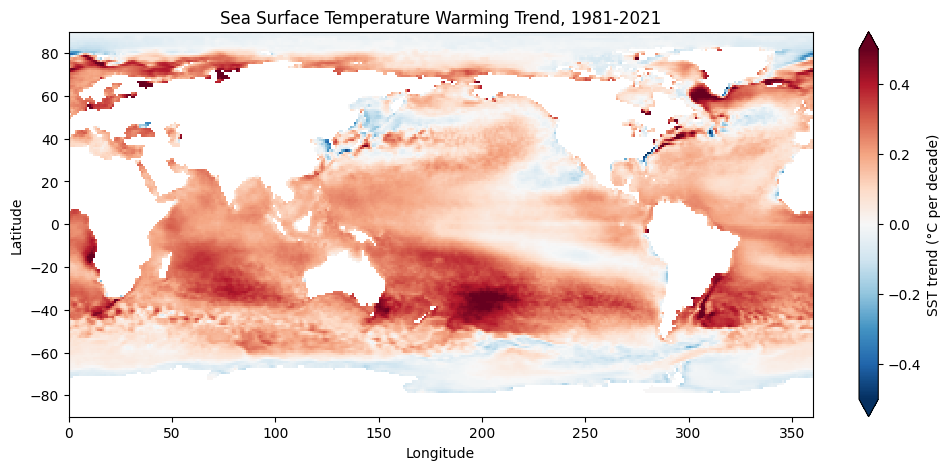

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

warming_rate_per_decade.plot(
    ax=ax,
    cmap="RdBu_r",
    vmin=-0.5,
    vmax=0.5,
    cbar_kwargs={"label": "SST trend (°C per decade)"}
)

ax.set_title("Sea Surface Temperature Warming Trend, 1981-2021")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [16]:
warming_total = float(global_mean_annual[-1] - global_mean_annual[0])
print(f"Total warming 1981–2021: {warming_total:.2f} °C")

# Hottest warming region
max_warming = float(warming_rate_per_decade.max())
print(f"Max warming rate: {max_warming:.2f} °C/decade")

Total warming 1981–2021: 0.64 °C
Max warming rate: 1.39 °C/decade


## Conclusion

Between 1981 and 2021, the global mean sea surface temperature in the NOAA OISST
dataset rose by approximately **0.64 °C** — averaging roughly **0.16 °C per decade**
across the global ocean.

The warming trend map reveals strong **spatial heterogeneity**:

- Some regions warmed at rates exceeding **1 °C per decade**, with a local maximum
  of approximately **1.39 °C/decade**. These hotspots are concentrated in the
  **Arctic Ocean and sub-polar North Atlantic**, where sea-ice retreat amplifies
  surface warming (the ice–albedo feedback).
- A few regions show weak cooling, including the well-documented
  **"warming hole"** south of Greenland, possibly linked to a slowdown of the
  Atlantic Meridional Overturning Circulation.
- The **eastern equatorial Pacific** warms more slowly than the global average,
  consistent with the observed La Niña-like trend in recent decades.

These patterns are consistent with published assessments (e.g. IPCC AR6 Ch. 9),
which find that high-latitude marginal seas and continental shelves have warmed
faster than the open tropical oceans.

**Limitations:**

- The trend map uses spatially coarsened (1°) annual data to keep computation
  tractable in Colab. A finer-resolution or seasonal analysis could reveal
  additional structure.
- A single linear trend masks any acceleration or decadal variability — the
  record is also affected by ENSO and AMO modes that are not removed here.
- The OISST product blends satellite and in-situ data; the dataset's own
  uncertainty (`err` variable) is not propagated in this analysis.